In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(tidyr)
library(ggsci)
library(patchwork)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
packageVersion("Seurat")
packageVersion("dplyr")
packageVersion("ggplot2")
packageVersion("tidyr")
packageVersion("ggsci")
packageVersion("patchwork")   #env

[1] ‘5.1.0’

[1] ‘1.1.4’

[1] ‘3.5.1’

[1] ‘1.3.1’

[1] ‘3.2.0’

[1] ‘1.2.0’

# 1. 载入数据与数据质量可视化

In [3]:
# 读取上一步 (Part 2) 生成的包含所有细胞的原始 Seurat 对象
sc <- readRDS('./Results/Test_Tilapia_Unfiltered.rds')
sc

An object of class Seurat 
15994 features across 1935 samples within 1 assay 
Active assay: RNA (15994 features, 0 variable features)
 2 layers present: counts.1, counts.2

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


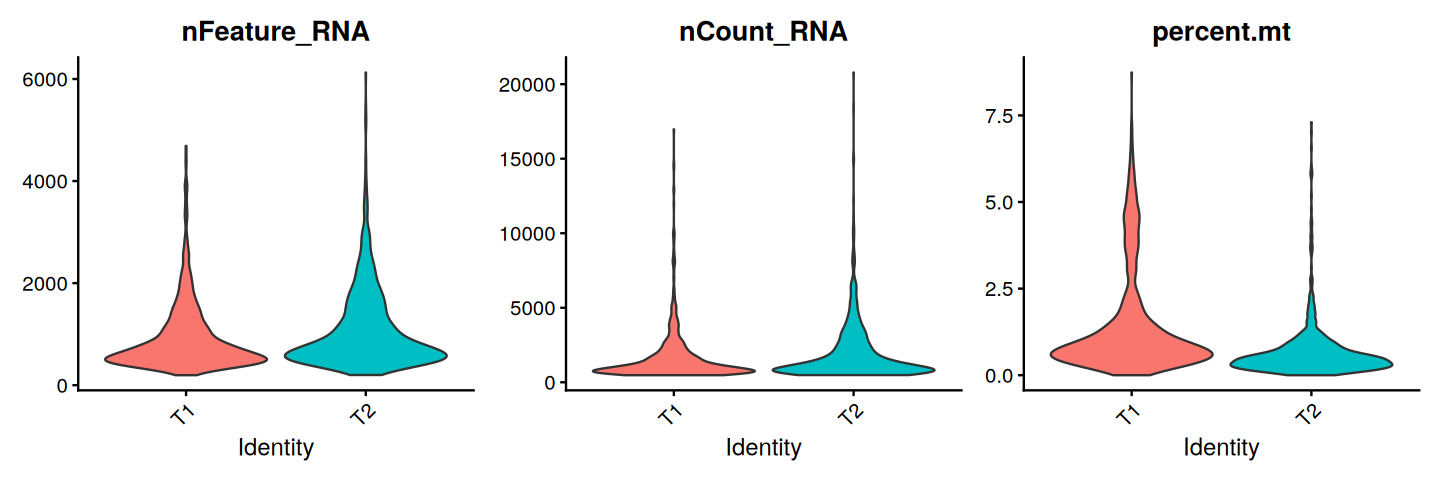

In [4]:
# 绘制小提琴图：按样本分别展示基因数(nFeature)、UMI总数(nCount)和线粒体占比(percent.mt)
options(repr.plot.width = 12,repr.plot.height = 4)
VlnPlot(sc, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3,group.by = 'sample',pt.size = 0)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 34 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 34 rows containing missing values or values outside the scale range
(`geom_point()`).”


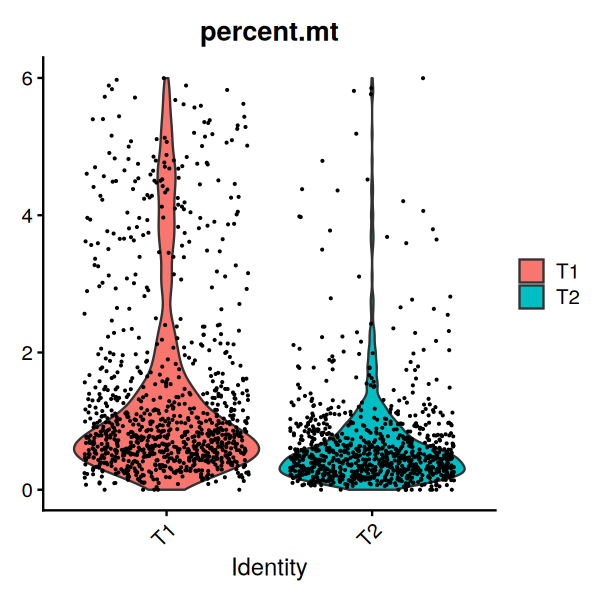

In [5]:
# 单独绘制线粒体占比的小提琴图，并强制限定 Y 轴范围，便于精细观察数据分布并确定截断阈值
options(repr.plot.width = 5,repr.plot.height = 5)
VlnPlot(sc, features = "percent.mt", group.by = "sample") +
  #geom_hline(yintercept = c(20, 25), linetype = "dashed", color = "red") +
  scale_y_continuous(
    breaks = seq(0, 7, by = 2),    # 从 0 到 6，每 2 为一个刻度
    limits = c(0, 6)               # 强制上下限
  )

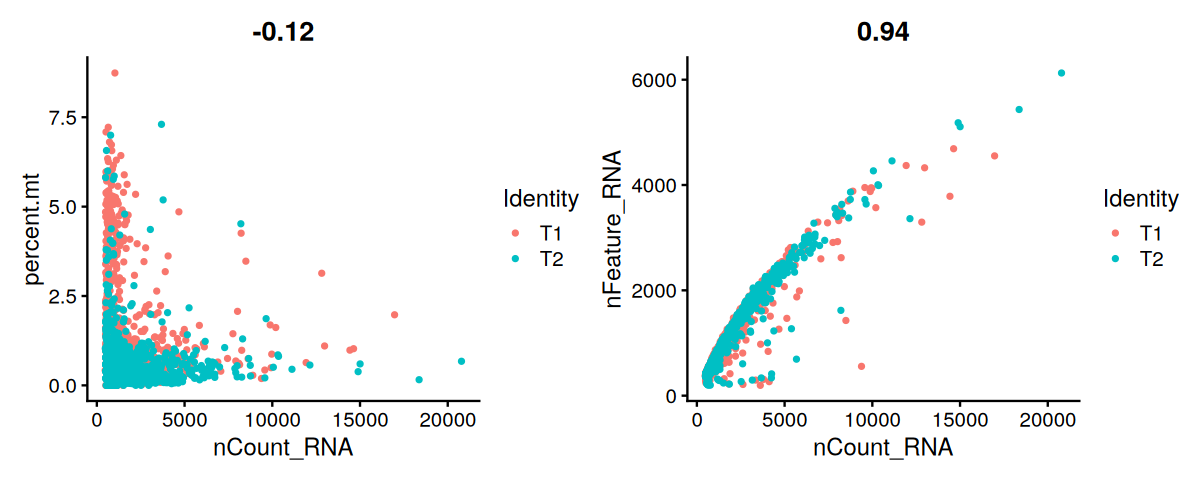

In [6]:
# 绘制散点图观察质控指标间的相关性
options(repr.plot.width = 10, repr.plot.height = 4)
# 测序深度 (nCount) 与 线粒体占比 (percent.mt) 的关系 (通常死细胞呈现低 nCount, 高 percent.mt)
plot1 <- FeatureScatter(sc, feature1 = "nCount_RNA", feature2 = "percent.mt",group.by = 'sample')
# 测序深度 (nCount) 与 基因数 (nFeature) 的关系 (正常细胞应呈明显的正相关线性关系)
plot2 <- FeatureScatter(sc, feature1 = "nCount_RNA", feature2 = "nFeature_RNA",group.by = 'sample')
plot1 + plot2

# 2. 动态阈值检测与细胞过滤 (质控)

In [7]:
# 计算动态阈值（供参考）：计算基因数的 1% 和 99% 分位数，以及线粒体的绝对中位差 (MAD)
qc_metrics <- list(
    sc.nFeature = quantile(sc$nFeature_RNA, probs = c(0.01, 0.99)),
    sc.percent.mt = median(sc$percent.mt) + 3 * mad(sc$percent.mt)
  )
qc_metrics

$sc.nFeature
     1%     99% 
 288.02 3725.32 

$sc.percent.mt
[1] 2.112829

In [8]:
sc

An object of class Seurat 
15994 features across 1935 samples within 1 assay 
Active assay: RNA (15994 features, 0 variable features)
 2 layers present: counts.1, counts.2

In [9]:
# 基础过滤：剔除低质量细胞（保留基因数 > 300 且 线粒体占比 < 5% 的细胞）
sc_filtered<- subset(sc, subset = nFeature_RNA > 300 & percent.mt < 5)
sc_filtered

An object of class Seurat 
15994 features across 1853 samples within 1 assay 
Active assay: RNA (15994 features, 0 variable features)
 2 layers present: counts.1, counts.2

In [10]:
# 上限过滤：剔除基因数异常高 (> 4000) 的细胞，这类细胞往往是未被成功识别的双细胞 (Doublets)
sc_filtered <- sc_filtered[,sc_filtered$nFeature_RNA < 4000]
sc_filtered

An object of class Seurat 
15994 features across 1842 samples within 1 assay 
Active assay: RNA (15994 features, 0 variable features)
 2 layers present: counts.1, counts.2

# 3. 数据标准化与初步降维聚类 (Unintegrated)

In [11]:
# 执行标准化
sc_filtered <- sc_filtered %>%
      NormalizeData(verbose = F) %>%                                          # 1. 表达量标准化 (LogNormalize)
      FindVariableFeatures(verbose = F) %>%                                   # 2. 寻找高变基因 (默认 2000 个)
      ScaleData(features = rownames(.), vars.to.regress = c("percent.mt", "nCount_RNA"),verbose = F) %>% # 3. 数据缩放并回归掉线粒体和深度带来的技术噪音
      RunPCA(verbose = FALSE) %>%                                             # 4. 线性降维 (PCA)
      FindNeighbors(reduction = "pca", dims = 1:30,verbose = F) %>%           # 5. 基于 PCA 构建 K-NN 邻接图
      FindClusters(resolution = c(0.1,0.2, 0.4, 0.8),cluster.name = c('unintegrated_clusters_0.1','unintegrated_clusters_0.2','unintegrated_clusters_0.4','unintegrated_clusters_0.8'),verbose = F) %>% # 6. 计算多个分辨率下的细胞聚类
      RunUMAP(reduction = "pca", dims = 1:30, reduction.name = "umap.unintegrated", verbose = FALSE)     # 7. 非线性降维 (UMAP) 用于可视化

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


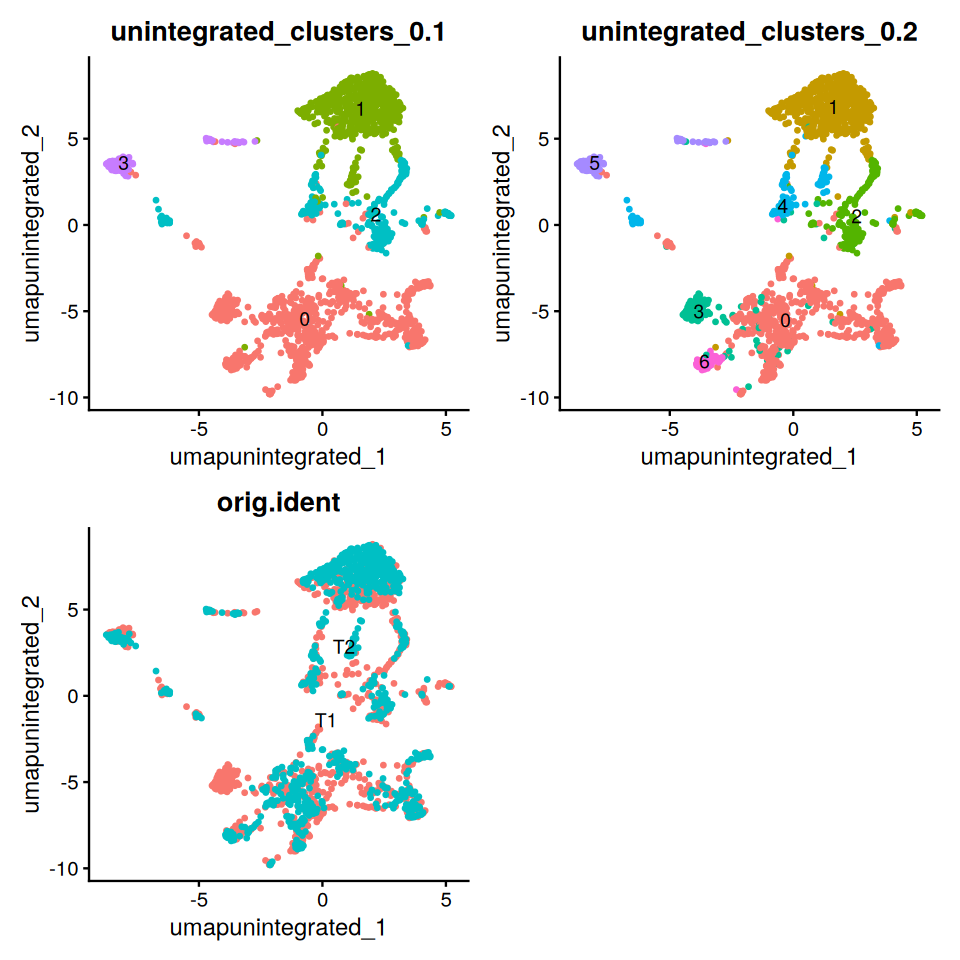

In [12]:
# 可视化整合前的 UMAP 分布，检查不同分辨率下的聚类情况以及样本/批次分布
options(repr.plot.width = 8, repr.plot.height = 8)
plot1 <- DimPlot(sc_filtered, reduction = "umap.unintegrated", label = T, group.by = "unintegrated_clusters_0.1") + NoLegend()
plot2 <- DimPlot(sc_filtered, reduction = "umap.unintegrated", label = T, group.by = "unintegrated_clusters_0.2") + NoLegend()
plot3 <- DimPlot(sc_filtered, reduction = "umap.unintegrated", label = T, group.by = "orig.ident") + NoLegend()
plot1 + plot2 + plot3 + plot_layout(nrow = 2)

In [13]:
# 查看过滤后各样本保留的细胞数
table(sc_filtered@meta.data$orig.ident)


 T1  T2 
920 922 

# 4. Harmony 批次效应校正 (数据整合)

In [14]:
# 使用 IntegrateLayers 函数执行 Harmony 批次整合
sc_filtered <- IntegrateLayers(
  object = sc_filtered, method = HarmonyIntegration,
  orig.reduction = "pca", new.reduction = "harmony",
  verbose = FALSE
)

Warning message:
“HarmonyMatrix is deprecated and will be removed in the future from the API in the future”
Warning message:
“Warning: The parameters do_pca and npcs are deprecated. They will be ignored for this function call and please remove parameters do_pca and npcs and pass to harmony cell_embeddings directly.
This warning is displayed once per session.”
Warning message:
“Warning: The parameter tau is deprecated. It will be ignored for this function call and please remove parameter tau in future function calls. Advanced users can set value of parameter tau by using parameter .options and function harmony_options().
This warning is displayed once per session.”
Warning message:
“Warning: The parameter block.size is deprecated. It will be ignored for this function call and please remove parameter block.size in future function calls. Advanced users can set value of parameter block.size by using parameter .options and function harmony_options().
This warning is displayed once per sessi

In [15]:
# 基于 Harmony 校正后的坐标空间重新进行寻找邻居、聚类和 UMAP 降维
sc_filtered <- sc_filtered %>%
  FindNeighbors(reduction = "harmony", dims = 1:30,verbose = F) %>%
  FindClusters(resolution = c(0.1,0.2,0.4,0.8),cluster.name = c('harmony_clusters_0.1','harmony_clusters_0.2','harmony_clusters_0.4','harmony_clusters_0.8'),verbose = F) %>%
  RunUMAP(reduction = "harmony", dims = 1:30,reduction.name = 'umap.harmony',verbose = FALSE)

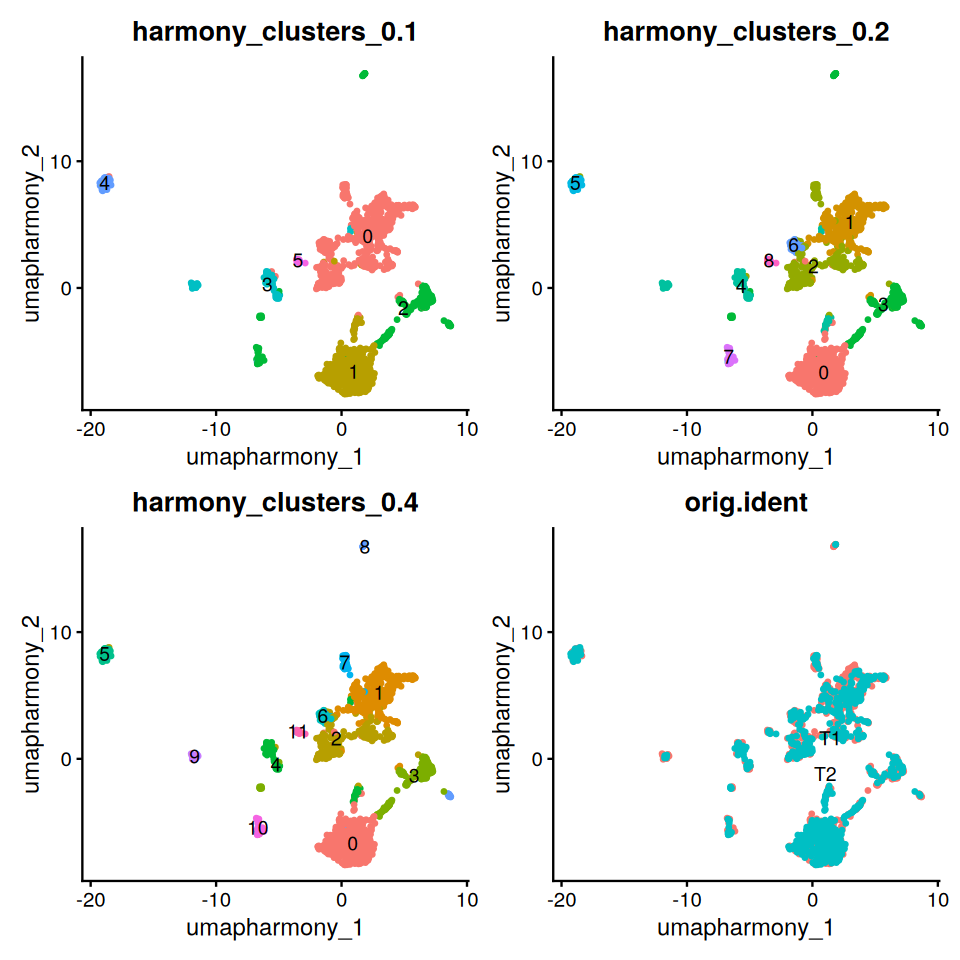

In [16]:
# 可视化 Harmony 整合后的结果 (分辨率 0.1, 0.2 ,0.4 以及批次混合情况)
options(repr.plot.width = 8, repr.plot.height = 8)
plot1 <- DimPlot(sc_filtered, reduction = "umap.harmony", label = T, group.by = "harmony_clusters_0.1") + NoLegend()
plot2 <- DimPlot(sc_filtered, reduction = "umap.harmony", label = T, group.by = "harmony_clusters_0.2") + NoLegend()
plot3 <- DimPlot(sc_filtered, reduction = "umap.harmony", label = T, group.by = "harmony_clusters_0.4") + NoLegend()
plot4 <- DimPlot(sc_filtered, reduction = "umap.harmony", label = T, group.by = "orig.ident") + NoLegend()
plot1 + plot2 + plot3 + plot4  + plot_layout(nrow = 2)

In [17]:
# 再次确认校正后的各样本细胞数
table(sc_filtered@meta.data$orig.ident)


 T1  T2 
920 922 

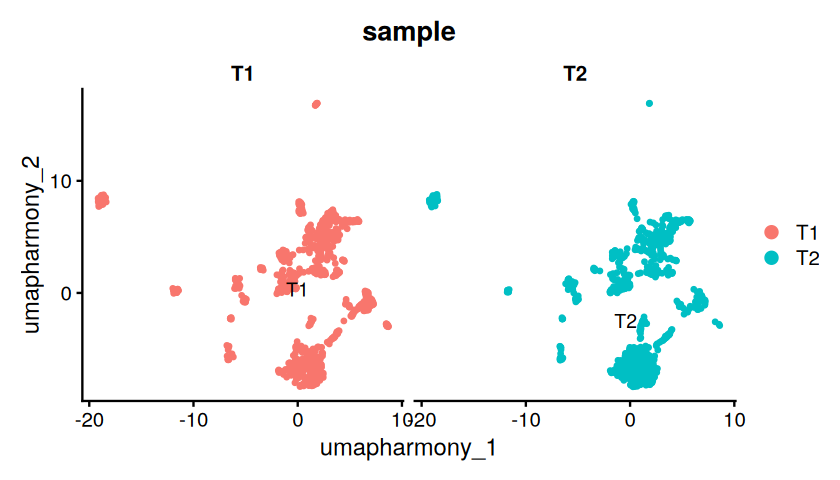

In [18]:
# 将不同批次/样本按面板拆分展示 (Split view)，检查细胞重叠度
options(repr.plot.width = 7, repr.plot.height = 4)
DimPlot(sc_filtered, reduction = "umap.harmony", label = T, group.by ="sample",repel = T,split.by = "orig.ident")

In [19]:
# 使用自定义的十六进制颜色代码 (ggsci风格) 对不同样本进行上色展示
sample_cols <- c('T1' = '#CC88B0', 'T2' = '#998DB7')

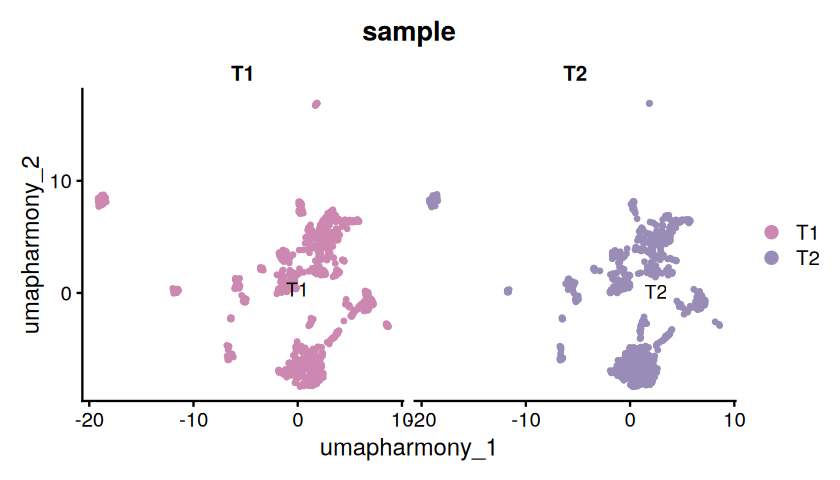

In [20]:
options(repr.plot.width = 7, repr.plot.height = 4)
DimPlot(sc_filtered, reduction = "umap.harmony", label = T, group.by ="sample",cols = sample_cols,repel = T,split.by = "orig.ident")

# 5. 结果保存

In [21]:
sc_filtered

An object of class Seurat 
15994 features across 1842 samples within 1 assay 
Active assay: RNA (15994 features, 2000 variable features)
 5 layers present: counts.1, counts.2, data.1, data.2, scale.data
 4 dimensional reductions calculated: pca, umap.unintegrated, harmony, umap.harmony

In [22]:
# 保存最终降维与整合完毕的 Seurat 对象，供后续亚群注释和差异分析使用
saveRDS(sc_filtered, file = "./Results/Test_Tilapia_harmony.rds")